# Dynamic Programming: Policy Iteration

This notebook runs full policy iteration on a deterministic GridWorld environment and visualizes the final value function, the improved policy, combined overlays, and convergence history.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(".."))

from envs.grid_world import GridWorld
from algorithms.policy_iteration import policy_iteration
from utils import (
    plot_value_grid,
    plot_policy_arrows,
    plot_value_and_policy,
    plot_convergence_comparison,
)

%matplotlib inline

## Environment Setup

We use a deterministic GridWorld with reproducible terminal states and a random initial policy.

In [2]:
env = GridWorld(n_rows=10, n_cols=15, seed=2026)

gamma = 0.95
seed = 84

print("Environment Configuration:")
print(f"  - Total Grid States: {len(env.states)}")
print(f"  - Terminal States: {env.terminal_states}")
print(f"  - Non-Terminal States: {len(env.non_terminal_states)}")
print(f"  - Available Actions: {env.ACTIONS}")

Environment Configuration:
  - Total Grid States: 150
  - Terminal States: [(2, 0), (5, 6)]
  - Non-Terminal States: 148
  - Available Actions: ['up', 'down', 'left', 'right']


## Policy Iteration Run

The algorithm alternates between policy evaluation and policy improvement until the policy becomes stable.

Policy iteration completed in 43956 Bellman backups.
Final delta value: 0.000000


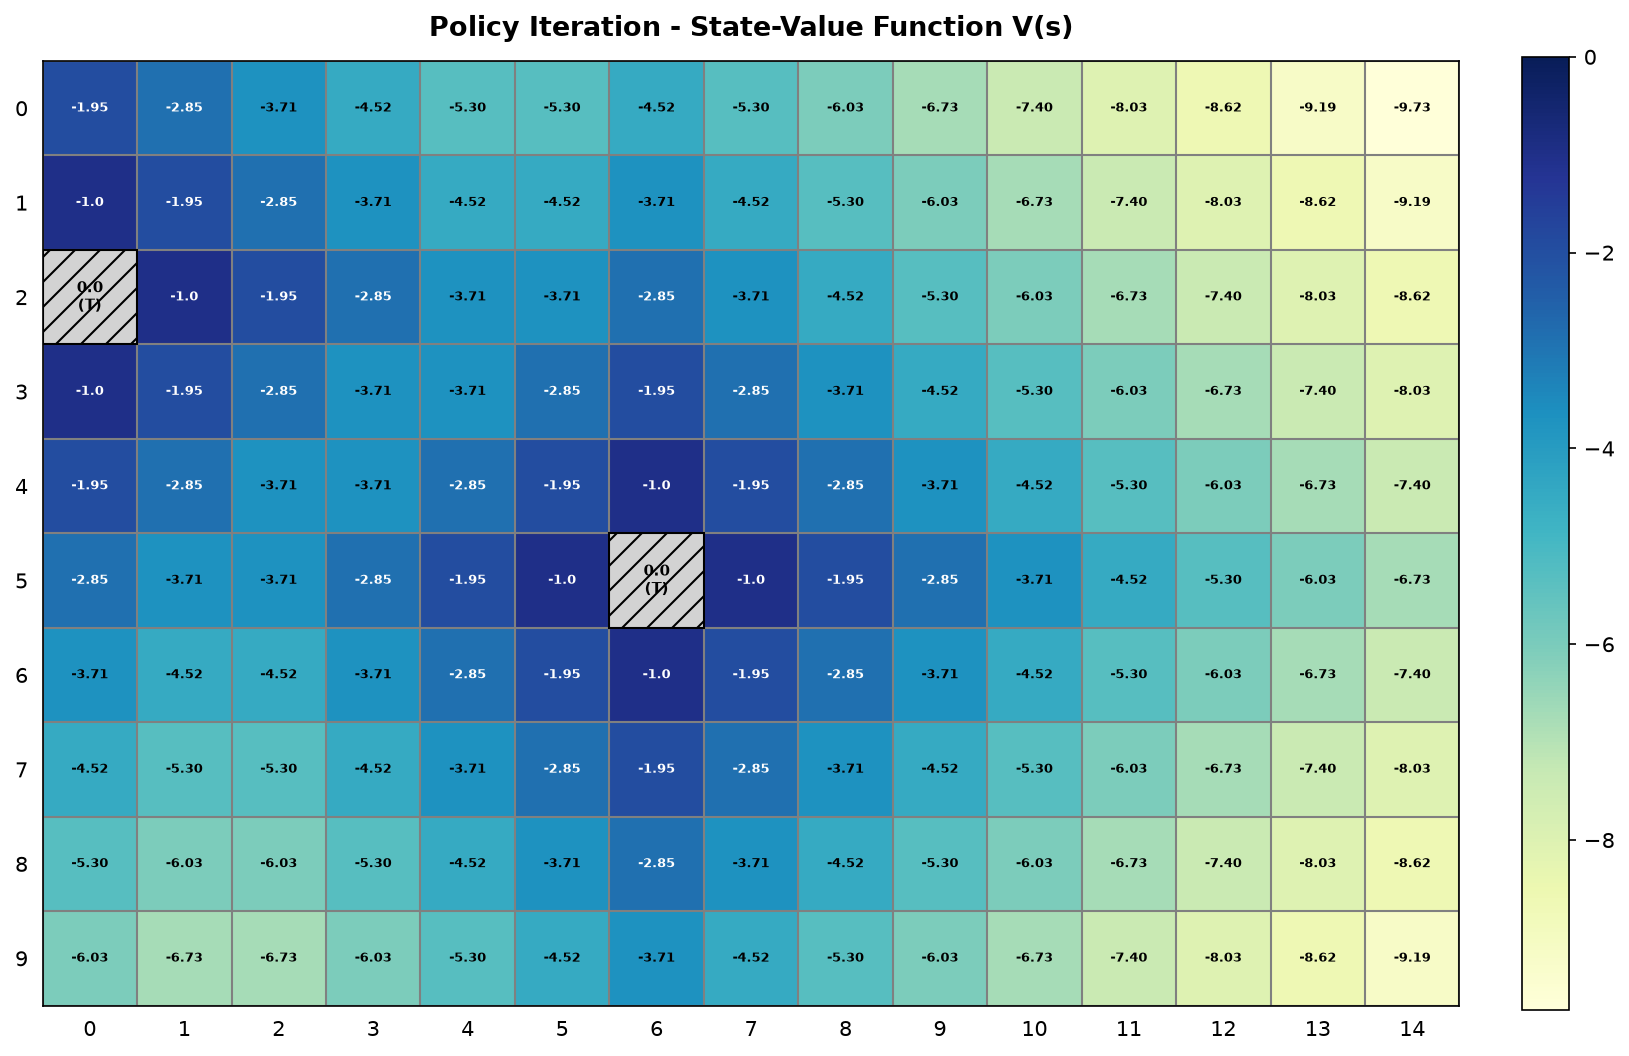

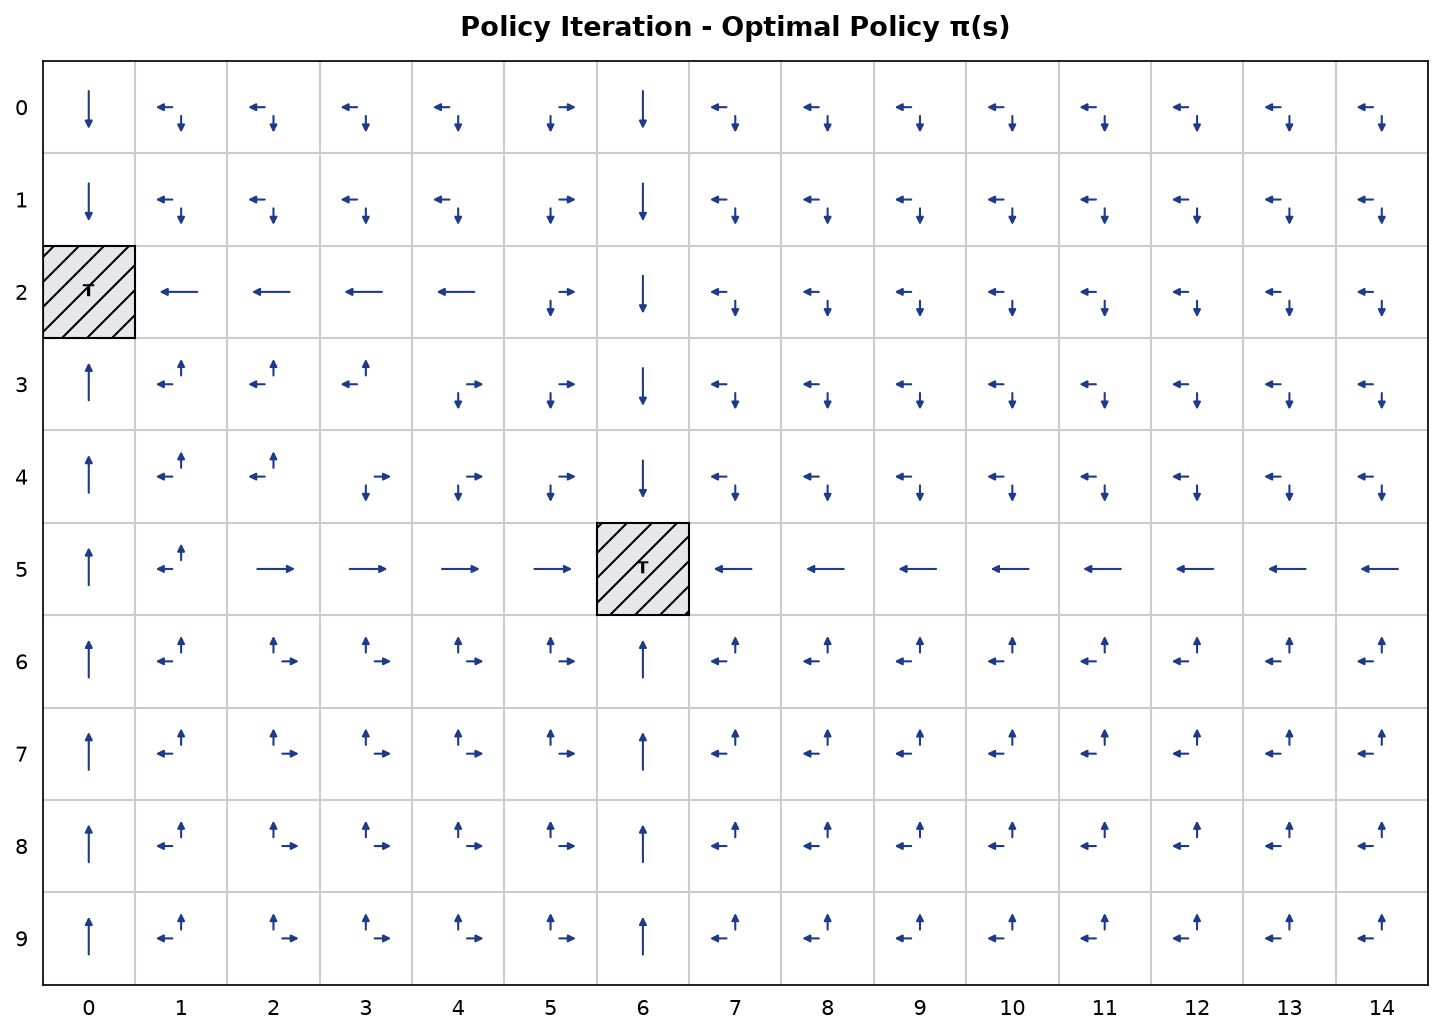

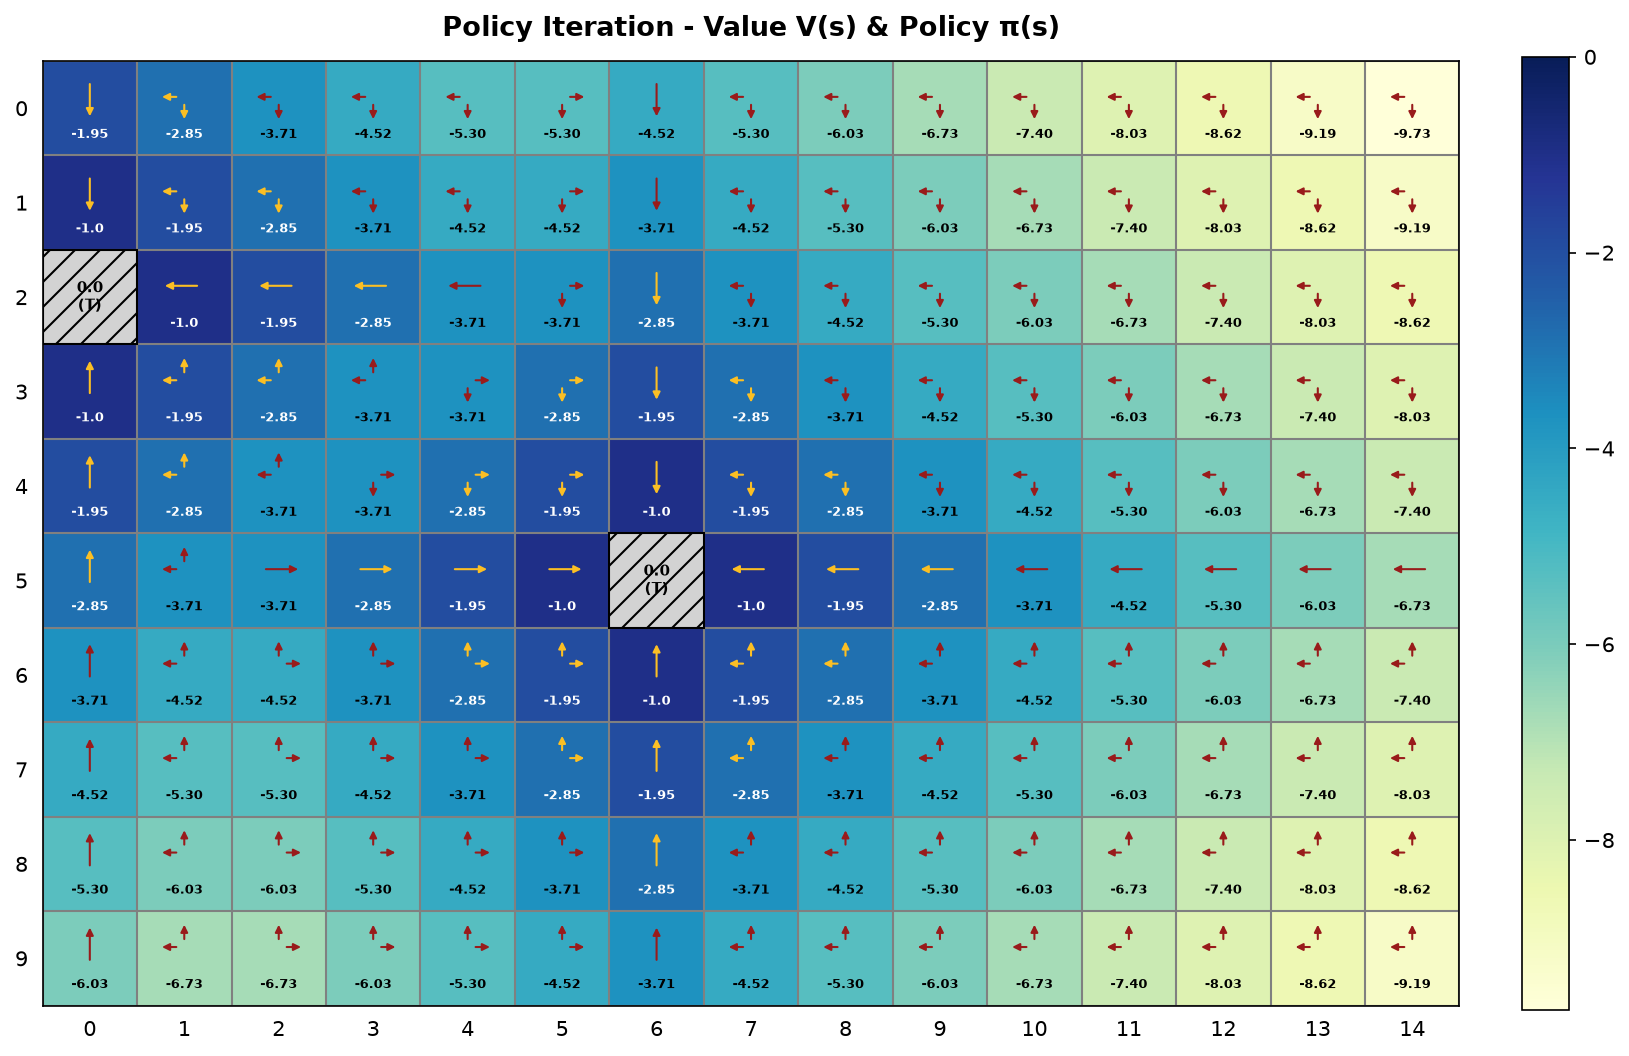

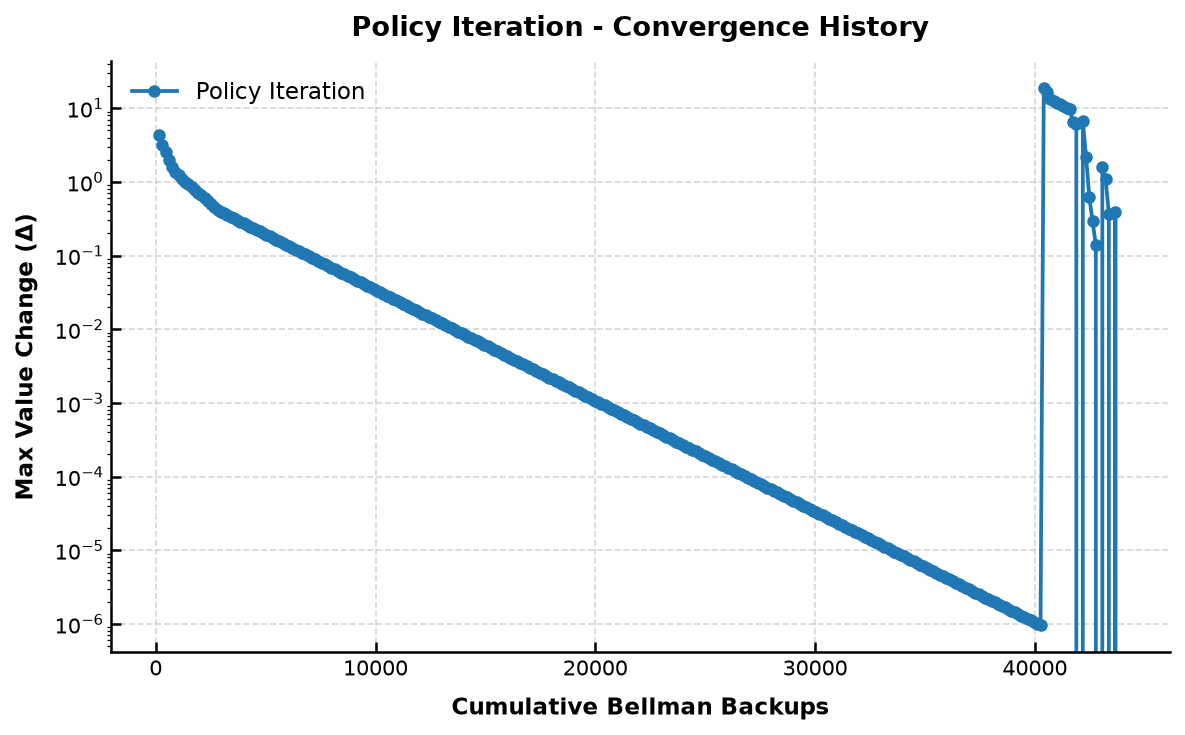

In [3]:
V_pi, pi_pi, history_pi = policy_iteration(
    env=env,
    gamma=gamma,
    seed=seed,
)

print(f"Policy iteration completed in {history_pi['backup_count'][-1]} Bellman backups.")
print(f"Final delta value: {history_pi['delta'][-1]:.6f}")

fig1, ax1 = plot_value_grid(
    env,
    V_pi,
    title="Policy Iteration - State-Value Function V(s)",
)
plt.show()

fig2, ax2 = plot_policy_arrows(
    env,
    pi_pi,
    title="Policy Iteration - Optimal Policy π(s)",
)
plt.show()

fig3, ax3 = plot_value_and_policy(
    env,
    V_pi,
    pi_pi,
    title="Policy Iteration - Value V(s) & Policy π(s)",
)
plt.show()

fig4, ax4 = plot_convergence_comparison(
    {"Policy Iteration": history_pi},
    log_scale=True,
    title="Policy Iteration - Convergence History",
)
plt.show()

## Remarks

Policy iteration converged to a stable policy and value function for this GridWorld setting. The first policy evaluation stage is the most expensive part of the run because the algorithm starts from a random policy and has to evaluate it thoroughly before the policy can improve. After that initial phase, the remaining updates become smaller and the policy stabilizes as expected.